<a href="https://colab.research.google.com/github/AnnaIordanidou/Composition-using-Pyramids/blob/main/Liquor_Sales_USA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

loading our data

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('https://storage.googleapis.com/courses_data/Assignment%20CSV/finance_liquor_sales.csv')
print(df.head())

  invoice_and_item_number        date  store_number  \
0         INV-31797900035  2020-11-10          4967   
1         INV-23548800092  2019-11-27          2601   
2         INV-23609300026  2019-12-02          4962   
3         INV-39482900037  2021-08-24          3719   
4         INV-39520400088  2021-08-25          5423   

                      store_name                   address          city  \
0     Jeff's Market / Blue Grass           102, W Mayne St    Blue Grass   
1  Hy-Vee Food Store / Fairfield  1300 West Burlington Ave     Fairfield   
2                Hilltop Grocery          1312 Harrison St     Davenport   
3   Wal-Mart 0581 / Marshalltown          2802 S Center St  Marshalltown   
4            Stammer Liquor Corp               615 2nd Ave       Sheldon   

   zip_code                store_location  county_number     county  ...  \
0   52726.0  POINT (-90.766126 41.509119)           82.0      SCOTT  ...   
1   52556.0  POINT (-91.978702 41.006456)           51.0  JE

checking for nan values and remove them
chosing only the data between 2016 and 2019

In [40]:
df.isna().sum()
df.dropna()
df['date'] = pd.to_datetime(df['date'])
data = df[(df['date'].dt.year>=2016) & (df['date'].dt.year<=2019)].reset_index()
print(data.head())

   index invoice_and_item_number       date  store_number  \
0      1         INV-23548800092 2019-11-27          2601   
1      2         INV-23609300026 2019-12-02          4962   
2      6            S30390600011 2016-01-26          2641   
3      7            S30348700047 2016-01-25          3162   
4      8            S30466200002 2016-02-01          2633   

                          store_name                   address  \
0      Hy-Vee Food Store / Fairfield  1300 West Burlington Ave   
1                    Hilltop Grocery          1312 Harrison St   
2  Hy-Vee Drugstore / Council Bluffs            757 W BROADWAY   
3        Nash Finch / Wholesale Food             807 GRANDVIEW   
4       Hy-Vee #3 / BDI / Des Moines           3221 SE 14TH ST   

             city  zip_code                        store_location  \
0       Fairfield   52556.0          POINT (-91.978702 41.006456)   
1       Davenport   52803.0                                   NaN   
2  COUNCIL BLUFFS   51501.0  

Group data by zip code and item number based on the sum of bottles_sold.

In [41]:
bottles_solded = data.groupby(['zip_code','item_number'])['bottles_sold'].sum().reset_index()
print(bottles_solded)


    zip_code  item_number  bottles_sold
0    50010.0       946574           288
1    50022.0        86507             4
2    50111.0        77805           108
3    50131.0        38089            48
4    50158.0        48099            24
..       ...          ...           ...
71   52627.0        67586            36
72   52732.0        45248            24
73   52761.0        82847             4
74   52803.0        41844             3
75   52804.0        48690             2

[76 rows x 3 columns]


for each zip_code, the index of the item_number that has the most bottles sold.



In [47]:
per = bottles_solded.groupby("zip_code")["bottles_sold"].idxmax()
max_bottles = bottles_solded.loc[per].reset_index()

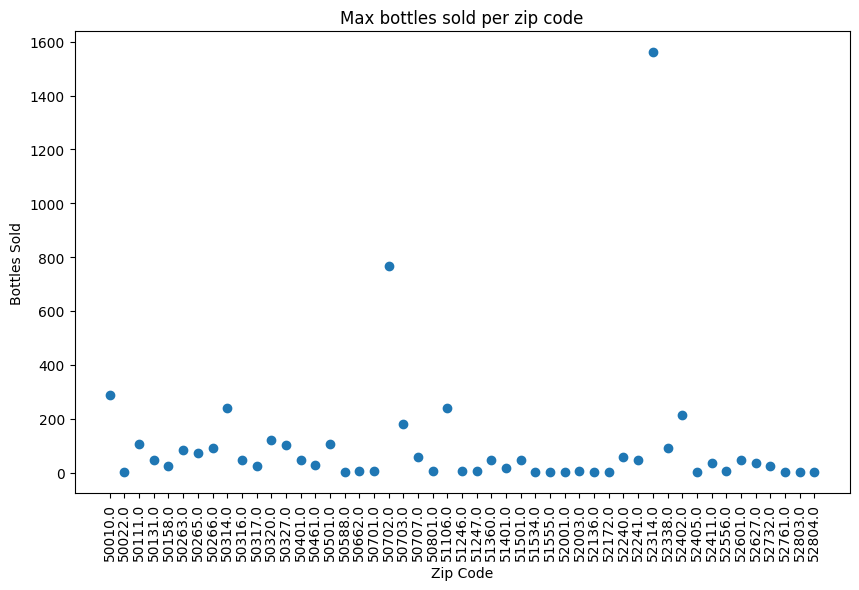

In [56]:
bottles_solded["zip_code"] = bottles_solded["zip_code"].astype(int)

plt.figure(figsize=(10,6))
plt.scatter(max_bottles["zip_code"].astype(str), max_bottles["bottles_sold"])
plt.xlabel("Zip Code")
plt.ylabel("Bottles Sold")
plt.title("Max bottles sold per zip code")
plt.xticks(rotation=90)
plt.show()

Compute the sales percentage per store (in dollars)


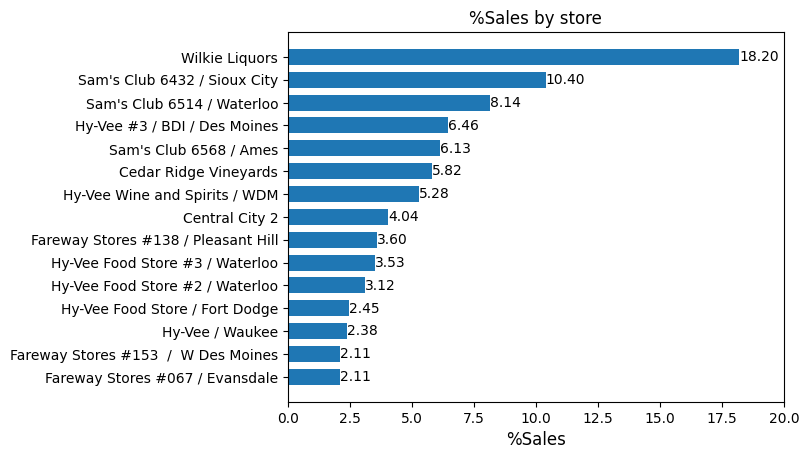

In [67]:
total_sales = sum(data['sale_dollars'])
sales = data.groupby('store_name')['sale_dollars'].sum()
percentage = (sales*100/total_sales).round(2)

percentage_sorted_sales = percentage.sort_values(ascending=True).tail(15)
p = plt.barh(percentage_sorted_sales.index, percentage_sorted_sales.values, height=0.7)
plt.title("%Sales by store")
plt.xlabel("%Sales", fontsize=12)
plt.bar_label(p, fmt="%.2f")
plt.xlim([0,20])
plt.show()